# CTC 可视化实验室：从路径求和到流式 Prefix Beam

这是第 10～14 课的贯通专题。它只使用 `{blank, A, B}` 和很小的概率矩阵，让每个数字都能被穷举验证。

完成后你应该能从一张 `[T, C]` 概率表出发，依次解释：

1. 一条逐帧路径怎样折叠成文本；
2. 为什么文本概率是多条路径概率之和；
3. CTC 前向算法怎样避免指数级枚举；
4. `CTCLoss` 的 shape、length 和不可能对齐为何会出错；
5. Prefix Beam 为什么必须保存 `p_blank` 与 `p_nonblank`；
6. 流式跨 chunk 时究竟要保存什么状态。

建议在完成第 10、11、12、13 课后分别回来做对应部分。第一次不要连续运行全部单元：先预测，再运行。


## 0. 一张总图：CTC 在训练和解码中扮演不同角色

```text
音频特征 [T,F] → 编码器 → logits [T,C] → log_softmax
                                      ├─ 训练：对所有目标合法路径求和 → CTCLoss
                                      └─ 解码：在所有可能文本中搜索 → Greedy / Prefix Beam
```

训练时目标文本已知，问题是“它的所有对齐共有多少概率”；解码时文本未知，问题是“哪个文本的累计概率最大”。二者都依赖同一个 CTC 折叠规则，但不是同一个算法。


<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36880 (\N{CJK UNIFIED IDEOGRAPH-9010}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

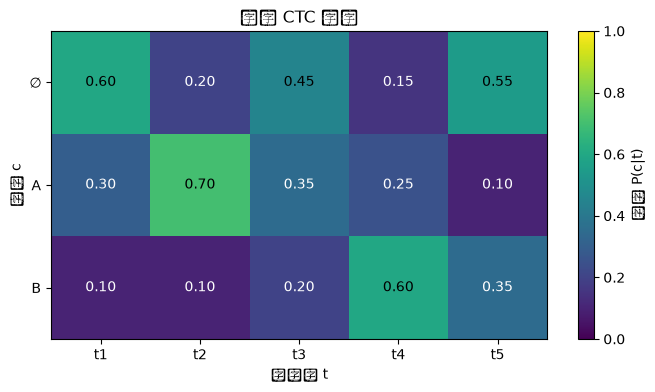

In [1]:
from __future__ import annotations

from collections import defaultdict
from itertools import product
import math

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, clear_output, display

# 小矩阵 CTCLoss 使用单线程，避免 Windows/OpenMP 为极小工作量启动大量线程。
torch.set_num_threads(1)

BLANK = "∅"
SYMBOLS = [BLANK, "A", "B"]
SYMBOL_TO_ID = {s: i for i, s in enumerate(SYMBOLS)}

# shape [T, C]：5 个时间步，每行是 blank/A/B 的概率分布。
P = np.array([
    [0.60, 0.30, 0.10],
    [0.20, 0.70, 0.10],
    [0.45, 0.35, 0.20],
    [0.15, 0.25, 0.60],
    [0.55, 0.10, 0.35],
], dtype=np.float64)

assert P.shape == (5, 3)
assert np.allclose(P.sum(axis=1), 1.0)
plt.rcParams["figure.figsize"] = (10, 4.5)

def draw_probability_table(probabilities=P, title="逐帧 CTC 概率"):
    fig, ax = plt.subplots(figsize=(8, 4))
    image = ax.imshow(probabilities.T, vmin=0, vmax=1, aspect="auto", cmap="viridis")
    for t in range(probabilities.shape[0]):
        for c in range(probabilities.shape[1]):
            value = probabilities[t, c]
            ax.text(t, c, f"{value:.2f}", ha="center", va="center",
                    color="white" if value < 0.45 else "black")
    ax.set(xticks=range(probabilities.shape[0]), xticklabels=[f"t{i+1}" for i in range(probabilities.shape[0])],
           yticks=range(len(SYMBOLS)), yticklabels=SYMBOLS,
           xlabel="时间步 t", ylabel="类别 c", title=title)
    fig.colorbar(image, ax=ax, label="概率 P(c|t)")
    plt.show()

draw_probability_table()


## 1. 第一层：折叠的是路径，不是概率表

CTC 折叠函数 $B(\pi)$ 必须严格按顺序执行：

1. 合并**相邻**重复；
2. 删除 blank。

所以 `A ∅ A → AA`，但 `A A → A`。blank 不是空格，也不等价于静音；它是 CTC 输出字母表中的特殊“不发出普通 token”类别。


In [2]:
def collapse(path, blank=BLANK):
    merged = []
    previous = None
    for symbol in path:
        if symbol != previous:
            merged.append(symbol)
        previous = symbol
    return "".join(symbol for symbol in merged if symbol != blank)

path_controls = [
    widgets.Dropdown(options=SYMBOLS, value=value, description=f"t{i+1}")
    for i, value in enumerate([BLANK, "A", "A", BLANK, "B"])
]
path_output = widgets.Output()

def update_path(*_):
    path = [control.value for control in path_controls]
    with path_output:
        clear_output(wait=True)
        colors = ["0.75" if x == BLANK else "C0" if x == "A" else "C1" for x in path]
        fig, ax = plt.subplots(figsize=(8, 2.2))
        ax.bar(range(len(path)), np.ones(len(path)), color=colors)
        for i, symbol in enumerate(path):
            ax.text(i, 0.5, symbol, ha="center", va="center", fontsize=16)
        ax.set(xticks=range(len(path)), xticklabels=[f"t{i+1}" for i in range(len(path))],
               yticks=[], ylim=(0, 1), title=f"B(path) = {collapse(path)!r}")
        plt.show()
        print("路径：", " ".join(path), "→ 文本：", repr(collapse(path)))

for control in path_controls:
    control.observe(update_path, names="value")
display(widgets.HBox(path_controls), path_output)
update_path()


Output()

### 立即检查

先不用代码，构造以下路径：

1. 折叠为 `AB`，并且 A 连续出现两帧；
2. 折叠为 `AA`；
3. 折叠为空字符串；
4. 看起来有两个 A，实际只折叠为一个 A。

如果第 2 题做不出，先不要进入动态规划，因为重复 token 正是 CTC 递推最容易写错的边界。


## 2. 第二层：路径概率与文本概率

在 CTC 的条件独立假设下，一条路径的概率是各时间步所选类别概率的乘积：

$$P(\pi\mid X)=\prod_{t=1}^{T}P(\pi_t\mid X,t)$$

一个文本的概率则把所有折叠成该文本的路径相加：

$$P(y\mid X)=\sum_{\pi:B(\pi)=y}P(\pi\mid X)$$

下面只有 $3^5=243$ 条路径，能够全部枚举。真实语音可能有数百帧，枚举会指数爆炸。


<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 25240 (\N{CJK UNIFIED IDEOGRAPH-6298}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21472 (\N{CJK UNIFIED IDEOGRAPH-53E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

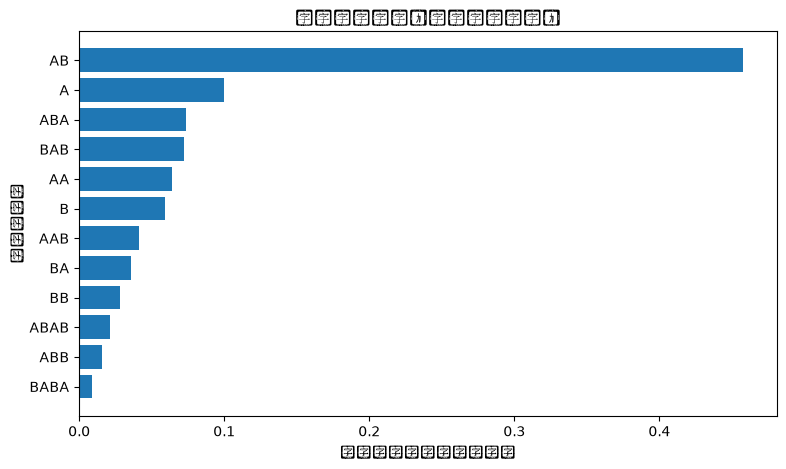

Greedy path: ∅ A ∅ B ∅ → 'AB' path P= 0.06237000000000001
概率最大的文本： 'AB' text P= 0.45795


In [3]:
def path_probability(path, probabilities=P):
    return float(np.prod([probabilities[t, SYMBOL_TO_ID[symbol]] for t, symbol in enumerate(path)]))

def exhaustive_text_probabilities(probabilities=P):
    totals = defaultdict(float)
    paths_by_text = defaultdict(list)
    for path in product(SYMBOLS, repeat=len(probabilities)):
        probability = path_probability(path, probabilities)
        text = collapse(path)
        totals[text] += probability
        paths_by_text[text].append((probability, path))
    return dict(totals), paths_by_text

text_totals, paths_by_text = exhaustive_text_probabilities()
assert np.isclose(sum(text_totals.values()), 1.0)

ranked = sorted(text_totals.items(), key=lambda item: item[1], reverse=True)
names = [text or "<空>" for text, _ in ranked[:12]]
values = [probability for _, probability in ranked[:12]]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(names[::-1], values[::-1])
ax.set(xlabel="所有合法路径的累计概率", ylabel="折叠后文本", title="文本概率排名（穷举得到真值）")
plt.show()

greedy_path = tuple(SYMBOLS[i] for i in P.argmax(axis=1))
print("Greedy path:", " ".join(greedy_path), "→", repr(collapse(greedy_path)), "path P=", path_probability(greedy_path))
print("概率最大的文本：", repr(ranked[0][0]), "text P=", ranked[0][1])


In [4]:
inspect_text = widgets.Dropdown(options=[text for text, _ in ranked], description="目标文本")
inspect_output = widgets.Output()

def show_paths(change=None):
    text = inspect_text.value
    paths = sorted(paths_by_text[text], reverse=True)
    with inspect_output:
        clear_output(wait=True)
        print(f"文本 {text!r} 共有 {len(paths)} 条合法路径，累计概率 {text_totals[text]:.8f}")
        print("概率最高的前 12 条：")
        for probability, path in paths[:12]:
            print(f"{probability:.8f}  {' '.join(path)}")

inspect_text.observe(show_paths, names="value")
display(inspect_text, inspect_output)
show_paths()


Dropdown(description='目标文本', options=('AB', 'A', 'ABA', 'BAB', 'AA', 'B', 'AAB', 'BA', 'BB', 'ABAB', 'ABB', 'B…

Output()

## 3. 第三层：把目标文本展开成 CTC 状态链

目标 `AB` 会扩展为：

```text
∅ → A → ∅ → B → ∅
```

每个时间步可以：

- 留在同一状态；
- 从前一状态前进；
- 在当前是普通 token、且不与前两个状态相同时，从前两个状态跳过中间 blank。

最后一条限制决定了 `AA` 不能直接从第一个 A 跳到第二个 A，必须经过 blank。


In [5]:
NEG_INF = -np.inf

def logsumexp(values):
    finite = [value for value in values if np.isfinite(value)]
    if not finite:
        return NEG_INF
    maximum = max(finite)
    return maximum + math.log(sum(math.exp(value - maximum) for value in finite))

def extend_target(target, blank=BLANK):
    extended = [blank]
    for token in target:
        extended.extend([token, blank])
    return extended

def ctc_forward_log(probabilities, target):
    logp = np.log(np.maximum(probabilities, 1e-300))
    extended = extend_target(target)
    T, S = len(probabilities), len(extended)
    alpha = np.full((T, S), NEG_INF, dtype=np.float64)
    alpha[0, 0] = logp[0, SYMBOL_TO_ID[BLANK]]
    if S > 1:
        alpha[0, 1] = logp[0, SYMBOL_TO_ID[extended[1]]]

    for t in range(1, T):
        for s, symbol in enumerate(extended):
            predecessors = [alpha[t - 1, s]]
            if s > 0:
                predecessors.append(alpha[t - 1, s - 1])
            if s > 1 and symbol != BLANK and symbol != extended[s - 2]:
                predecessors.append(alpha[t - 1, s - 2])
            alpha[t, s] = logp[t, SYMBOL_TO_ID[symbol]] + logsumexp(predecessors)

    endings = [alpha[-1, -1]]
    if S > 1:
        endings.append(alpha[-1, -2])
    return logsumexp(endings), alpha, extended

for target in ["A", "B", "AB", "AA", "ABA"]:
    log_probability, alpha, extended = ctc_forward_log(P, target)
    exact = text_totals.get(target, 0.0)
    print(f"target={target!r}  forward={math.exp(log_probability):.10f}  exhaustive={exact:.10f}  diff={abs(math.exp(log_probability)-exact):.2e}")


target='A'  forward=0.0995137500  exhaustive=0.0995137500  diff=1.39e-17
target='B'  forward=0.0589912500  exhaustive=0.0589912500  diff=3.47e-17
target='AB'  forward=0.4579500000  exhaustive=0.4579500000  diff=1.11e-16
target='AA'  forward=0.0641962500  exhaustive=0.0641962500  diff=1.39e-17
target='ABA'  forward=0.0735487500  exhaustive=0.0735487500  diff=2.78e-17


In [6]:
target_widget = widgets.Dropdown(options=["A", "B", "AB", "AA", "ABA"], value="AB", description="目标")
time_widget = widgets.IntSlider(min=1, max=len(P), value=len(P), description="已处理帧")
forward_output = widgets.Output()

def show_forward(*_):
    target = target_widget.value
    used = time_widget.value
    log_probability, alpha, extended = ctc_forward_log(P[:used], target)
    shown = np.where(np.isfinite(alpha), alpha, np.nan)
    with forward_output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(max(8, len(extended) * 1.2), 4.5))
        image = ax.imshow(shown.T, aspect="auto", cmap="magma")
        for t in range(alpha.shape[0]):
            for s in range(alpha.shape[1]):
                label = "×" if not np.isfinite(alpha[t, s]) else f"{alpha[t, s]:.2f}"
                ax.text(t, s, label, ha="center", va="center", color="white", fontsize=9)
        ax.set(xticks=range(used), xticklabels=[f"t{i+1}" for i in range(used)],
               yticks=range(len(extended)), yticklabels=[f"s{i}:{x}" for i, x in enumerate(extended)],
               xlabel="时间步", ylabel="扩展目标状态", title=f"log α(t,s)：target={target!r}")
        fig.colorbar(image, ax=ax, label="累计 log probability")
        plt.show()
        minimum = len(target) + sum(a == b for a, b in zip(target, target[1:]))
        print(f"目标最少需要 {minimum} 帧；当前有 {used} 帧。")
        print("最终 log P：", log_probability, "｜P：", 0.0 if not np.isfinite(log_probability) else math.exp(log_probability))

for control in [target_widget, time_widget]:
    control.observe(show_forward, names="value")
display(widgets.HBox([target_widget, time_widget]), forward_output)
show_forward()


Output()

### 怎样读前向热力图

- 横轴是已经处理到的时间步，纵轴是扩展目标中的状态；
- `×` 表示该状态在那个时间不可能到达；
- 每个格子不是“这一帧属于哪个字”，而是“所有到达这里的部分路径概率之和的 log”；
- 最终概率来自最后一个 blank 状态和最后一个 token 状态；
- 把目标从 `AB` 改为 `AA`，观察被禁止的跨越如何改变可达区域。

检查点：你应能用手指着任意格子，说出它最多来自哪三个前驱状态，以及为什么某些 `s-2` 跳转被禁止。


## 4. 第四层：与 `torch.nn.CTCLoss` 对齐

PyTorch 的关键契约：

- `log_probs`：`[T, N, C]`，必须是 log probability；
- `targets`：拼接的一维目标或 `[N, S]`；
- `input_lengths`：每个样本有效的编码器时间步；
- `target_lengths`：每个目标有效 token 数；
- blank id 不能作为普通目标 token。

`zero_infinity=True` 会把不可能对齐产生的无穷 loss 和梯度变为 0，能防止训练炸掉，但也可能掩盖数据或下采样长度错误。因此必须单独统计“不可能样本比例”。


In [7]:
def torch_ctc_loss_for(target, probabilities=P, zero_infinity=False):
    token_ids = torch.tensor([SYMBOL_TO_ID[x] for x in target], dtype=torch.long)
    log_probs = torch.tensor(np.log(probabilities), dtype=torch.float64).unsqueeze(1)  # [T, N=1, C]
    input_lengths = torch.tensor([len(probabilities)], dtype=torch.long)
    target_lengths = torch.tensor([len(target)], dtype=torch.long)
    loss_fn = torch.nn.CTCLoss(blank=0, reduction="none", zero_infinity=zero_infinity)
    return float(loss_fn(log_probs, token_ids, input_lengths, target_lengths)[0])

for target in ["A", "AB", "AA", "ABA"]:
    forward_logp, _, _ = ctc_forward_log(P, target)
    torch_loss = torch_ctc_loss_for(target)
    print(f"{target!r}: -forward logP={-forward_logp:.10f}, torch loss={torch_loss:.10f}, diff={abs(-forward_logp-torch_loss):.2e}")

# 不可能对齐：AA 至少 3 帧，这里只给 2 帧。
impossible_loss = torch_ctc_loss_for("AA", P[:2], zero_infinity=False)
hidden_loss = torch_ctc_loss_for("AA", P[:2], zero_infinity=True)
print("AA with T=2, zero_infinity=False:", impossible_loss)
print("AA with T=2, zero_infinity=True :", hidden_loss, "← 训练不会报炸，但样本没有学习信号")


'A': -forward logP=2.3074594534, torch loss=2.3074594534, diff=0.00e+00
'AB': -forward logP=0.7809952711, torch loss=0.7809952711, diff=0.00e+00
'AA': -forward logP=2.7458104812, torch loss=2.7458104812, diff=0.00e+00
'ABA': -forward logP=2.6098068273, torch loss=2.6098068273, diff=0.00e+00
AA with T=2, zero_infinity=False: inf
AA with T=2, zero_infinity=True : 0.0 ← 训练不会报炸，但样本没有学习信号


In [8]:
def audit_ctc_sample(target, input_steps, class_count=3, blank_id=0):
    problems = []
    minimum_steps = len(target) + sum(a == b for a, b in zip(target, target[1:]))
    if input_steps < minimum_steps:
        problems.append(f"不可能对齐：T={input_steps} < 最少 {minimum_steps}")
    unknown = [token for token in target if token not in SYMBOL_TO_ID]
    if unknown:
        problems.append(f"目标含未知 token：{unknown}")
    if any(SYMBOL_TO_ID.get(token) == blank_id for token in target):
        problems.append("目标错误地包含 blank")
    if class_count != len(SYMBOLS):
        problems.append(f"类别数不一致：模型 C={class_count}，词表需要 {len(SYMBOLS)}")
    return problems or ["通过结构检查；仍需验证 log_softmax 维度、batch length 和数值范围"]

audit_target = widgets.Text(value="AA", description="目标")
audit_steps = widgets.IntSlider(min=1, max=8, value=2, description="输入 T")
audit_output = widgets.Output()

def show_audit(*_):
    with audit_output:
        clear_output(wait=True)
        for message in audit_ctc_sample(audit_target.value, audit_steps.value):
            print("-", message)

for control in [audit_target, audit_steps]:
    control.observe(show_audit, names="value")
display(widgets.HBox([audit_target, audit_steps]), audit_output)
show_audit()


Output()

## 5. 第五层：梯度不是“把每帧贴到一个字”

CTC loss 会对所有合法对齐求和。梯度推动的是：增加目标文本的**总路径概率**，不是先秘密选定一条人工对齐再做逐帧交叉熵。

下面把 logits 当成可学习参数，观察目标 `AB` 的梯度。负梯度较大的位置表示梯度下降会倾向提高那个类别的 logit；但具体模式同时受 softmax 竞争和所有路径后验影响。


<USER_HOME>\AppData\Local\Temp\ipykernel_12648\1838808307.py:21: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<USER_HOME>\AppData\Local\Temp\ipykernel_12648\1838808307.py:21: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<USER_HOME>\AppData\Local\Temp\ipykernel_12648\1838808307.py:21: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<USER_HOME>\AppData\Local\Temp\ipykernel_12648\1838808307.py:21: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<USER_HOME>\AppData\Local\Temp\ipykernel_12648\1838808307.py:21: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<USER_HOME>\AppData\Local\Temp\ipykernel_12648\1838808307.py:21: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEO

<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

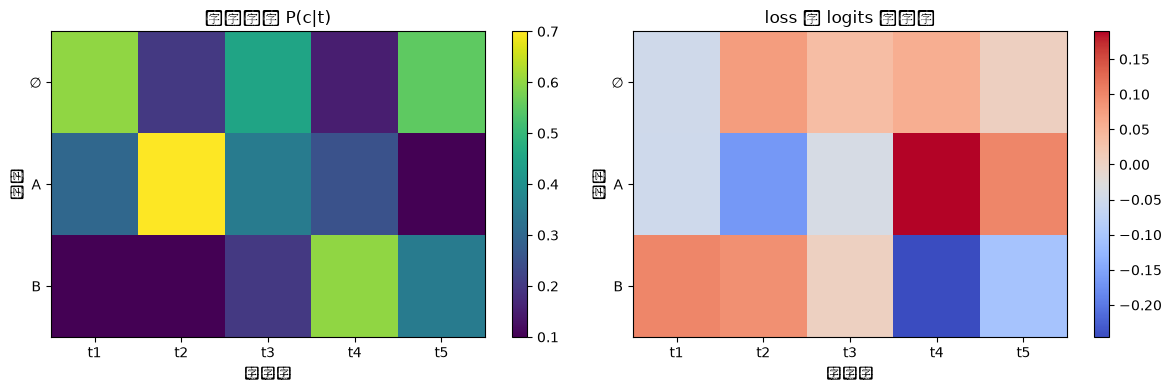

loss = 0.7809952711331407 ｜每一帧梯度行和应接近 0： [ 0.00000000e+00  0.00000000e+00 -4.33680869e-18  0.00000000e+00
  0.00000000e+00]


<USER_HOME>\AppData\Local\Temp\ipykernel_12648\1838808307.py:23: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  print("loss =", float(loss), "｜每一帧梯度行和应接近 0：", gradient.sum(axis=1))


In [9]:
logits = torch.tensor(np.log(P), dtype=torch.float64, requires_grad=True)
log_probs = logits.log_softmax(dim=-1).unsqueeze(1)
loss = torch.nn.CTCLoss(blank=0, reduction="sum")(
    log_probs,
    torch.tensor([1, 2], dtype=torch.long),
    torch.tensor([len(P)]),
    torch.tensor([2]),
)
loss.backward()
gradient = logits.grad.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, matrix, title, cmap in [
    (axes[0], P.T, "初始概率 P(c|t)", "viridis"),
    (axes[1], gradient.T, "loss 对 logits 的梯度", "coolwarm"),
]:
    image = ax.imshow(matrix, aspect="auto", cmap=cmap)
    ax.set(xticks=range(len(P)), xticklabels=[f"t{i+1}" for i in range(len(P))],
           yticks=range(3), yticklabels=SYMBOLS, xlabel="时间步", ylabel="类别", title=title)
    fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()
print("loss =", float(loss), "｜每一帧梯度行和应接近 0：", gradient.sum(axis=1))


## 6. 第六层：Prefix Beam Search 是按文本前缀合并路径

Greedy 每帧只保留一个类别，容易丢掉“许多次优路径加起来翻盘”的文本。Prefix Beam 把折叠后前缀相同的路径合并，并为每个前缀保存：

- `p_b(prefix)`：以 blank 结尾的路径概率和；
- `p_nb(prefix)`：以非 blank 结尾的路径概率和。

如果只保存一个总概率，就无法正确区分 `A A`（仍为 A）和 `A ∅ A`（变为 AA）。


In [10]:
def prefix_beam_step(beam, frame_probabilities, beam_size):
    next_beam = defaultdict(lambda: [0.0, 0.0])
    for prefix, (p_blank, p_nonblank) in beam.items():
        for class_id, symbol in enumerate(SYMBOLS):
            probability = float(frame_probabilities[class_id])
            if symbol == BLANK:
                next_beam[prefix][0] += (p_blank + p_nonblank) * probability
            elif prefix and symbol == prefix[-1]:
                next_beam[prefix][1] += p_nonblank * probability
                next_beam[prefix + symbol][1] += p_blank * probability
            else:
                next_beam[prefix + symbol][1] += (p_blank + p_nonblank) * probability
    ranked_items = sorted(next_beam.items(), key=lambda item: sum(item[1]), reverse=True)
    return {prefix: tuple(scores) for prefix, scores in ranked_items[:beam_size]}

def prefix_beam_search(probabilities, beam_size=10, initial_beam=None):
    beam = {"": (1.0, 0.0)} if initial_beam is None else dict(initial_beam)
    history = []
    for frame in probabilities:
        beam = prefix_beam_step(beam, frame, beam_size)
        history.append(beam)
    return beam, history

full_beam, beam_history = prefix_beam_search(P, beam_size=100)
for prefix, scores in sorted(full_beam.items(), key=lambda item: sum(item[1]), reverse=True)[:10]:
    exact = text_totals.get(prefix, 0.0)
    print(f"{prefix!r:6} beam={sum(scores):.10f} exhaustive={exact:.10f} pb={scores[0]:.6f} pnb={scores[1]:.6f}")


'AB'   beam=0.4579500000 exhaustive=0.4579500000 pb=0.249604 pnb=0.208346
'A'    beam=0.0995137500 exhaustive=0.0995137500 pb=0.090791 pnb=0.008722
'ABA'  beam=0.0735487500 exhaustive=0.0735487500 pb=0.023966 pnb=0.049582
'BAB'  beam=0.0723275000 exhaustive=0.0723275000 pb=0.034650 pnb=0.037677
'AA'   beam=0.0641962500 exhaustive=0.0641962500 pb=0.047314 pnb=0.016883
'B'    beam=0.0589912500 exhaustive=0.0589912500 pb=0.036836 pnb=0.022155
'AAB'  beam=0.0414487500 exhaustive=0.0414487500 pb=0.006930 pnb=0.034519
'BA'   beam=0.0357725000 exhaustive=0.0357725000 pb=0.025713 pnb=0.010060
'BB'   beam=0.0284812500 exhaustive=0.0284812500 pb=0.015015 pnb=0.013466
'ABAB' beam=0.0209212500 exhaustive=0.0209212500 pb=0.003465 pnb=0.017456


In [11]:
@widgets.interact(
    beam_size=widgets.SelectionSlider(options=[1, 2, 3, 5, 10, 100], value=5, description="beam size"),
    used=widgets.IntSlider(min=1, max=len(P), value=1, description="已处理帧"),
)
def show_beam(beam_size=5, used=1):
    beam, history = prefix_beam_search(P[:used], beam_size=beam_size)
    items = sorted(beam.items(), key=lambda item: sum(item[1]), reverse=True)
    names = [prefix or "<空>" for prefix, _ in items]
    totals = [sum(scores) for _, scores in items]
    fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(items))))
    ax.barh(names[::-1], totals[::-1])
    ax.set(xlabel="prefix probability", ylabel="前缀", title=f"处理 {used} 帧后的 beam（size={beam_size}）")
    plt.show()
    best_prefix, best_scores = items[0]
    print("当前最佳文本：", repr(best_prefix), "累计概率：", sum(best_scores))
    if beam_size == 1:
        print("beam=1 不等价于始终正确的文本搜索；早期剪枝后，后续无法恢复被删前缀。")


interactive(children=(SelectionSlider(description='beam size', index=3, options=(1, 2, 3, 5, 10, 100), value=5…

## 7. 第七层：流式不是每个 chunk 从空字符串重新解码

假设 5 帧被切成前 2 帧和后 3 帧。正确做法是把第一个 chunk 结束时的整个 beam 状态传给下一个 chunk。只传当前最佳字符串会丢掉竞争前缀；完全重置则把两段当成两句话。


In [12]:
beam_size = 100
offline_beam, _ = prefix_beam_search(P, beam_size=beam_size)

chunk1_beam, _ = prefix_beam_search(P[:2], beam_size=beam_size)
streaming_beam, _ = prefix_beam_search(P[2:], beam_size=beam_size, initial_beam=chunk1_beam)

all_prefixes = set(offline_beam) | set(streaming_beam)
max_difference = max(
    abs(offline_beam.get(prefix, (0.0, 0.0))[i] - streaming_beam.get(prefix, (0.0, 0.0))[i])
    for prefix in all_prefixes for i in [0, 1]
)
print("完整一次解码的最佳项：", max(offline_beam.items(), key=lambda item: sum(item[1])))
print("跨 chunk 保留状态的最佳项：", max(streaming_beam.items(), key=lambda item: sum(item[1])))
print("两种方式最大状态差：", max_difference)
assert max_difference < 1e-12

reset_beam, _ = prefix_beam_search(P[2:], beam_size=beam_size)
print("错误地在 chunk2 重置后的最佳项：", max(reset_beam.items(), key=lambda item: sum(item[1])))


完整一次解码的最佳项： ('AB', (0.24960374999999999, 0.20834624999999996))
跨 chunk 保留状态的最佳项： ('AB', (0.24960374999999999, 0.20834624999999996))
两种方式最大状态差： 0.0
错误地在 chunk2 重置后的最佳项： ('B', (0.23100000000000004, 0.160125))


### 流式系统真正要保存的状态

至少包括：

1. 在线特征提取剩余的采样点或帧；
2. 编码器卷积、注意力或循环状态；
3. Prefix Beam 中多个候选及各自的 `p_b/p_nb`；
4. 语言模型或 WFST 的状态；
5. 已提交稳定文本和仍可修改的暂定文本；
6. endpoint、会话 id、时间戳与资源回收状态。

“接口每次收到一个 chunk”只说明输入是分块的，不足以证明系统是正确的流式 ASR。


## 8. 最终闭卷测试（32 分）

每题 0～2 分：0=不会；1=方向正确；2=能用公式、数字或代码验证。达到 **26/32** 才算本专题通过。

### 概念与手算

1. 不看代码，写出 `A A ∅ A ∅ B B` 的折叠结果和两个中间步骤。
2. 解释 blank 为什么既不是空格，也不能简单称为静音。
3. 目标 `BOOKKEEPER` 最少需要多少编码器时间步？写出计算过程。
4. 路径概率最大为什么不保证文本概率最大？
5. 前向变量 $\alpha(t,s)$ 表示什么？它为什么不是逐帧标签？
6. 一个普通非重复 token 状态最多有哪三个前驱？
7. 为什么相邻重复 token 会禁止某些 `s-2` 跳转？
8. 最终文本概率为什么同时看最后 token 和末尾 blank 两个状态？

### 编程与排错

9. 从空白写 `collapse`，至少测试空路径、全 blank、重复字符和被 blank 隔开的重复字符。
10. 从空白实现线性空间或 log-space 前向算法，并与穷举结果对照。
11. 构造一个 `T < U + adjacent_repeats` 的样本，比较 `zero_infinity=False/True`。
12. 故意把 `log_softmax` 做在时间维，记录 loss 和概率归一化检查怎样暴露错误。
13. 写 batch audit，统计不可能对齐样本数量和比例。
14. 从空白写 Prefix Beam，并用穷举文本概率验证 beam 足够大时的结果。
15. 将概率矩阵随机切成 chunk，证明保留完整 beam state 与离线结果一致。
16. 只跨 chunk 保存最佳字符串，构造一个结果不同的反例。

### 通关表达

你还需要完成一次 5 分钟白板讲解：从 `[T,C]` 开始，画出扩展目标、前向表、`CTCLoss` 输入、Prefix Beam 状态和跨 chunk 状态。任何一个箭头都要说清 shape、概率/对数概率以及是否属于训练或解码。


<details><summary>展开关键答案与评分锚点</summary>

1. 先合并相邻重复：`A ∅ A ∅ B`；再删 blank：`AAB`。
2. blank 是建模未知对齐的特殊类别；空格可以是普通文本 token，静音也可能对应许多声学状态。
3. `BOOKKEEPER` 有 `OO`、`KK`、`EE` 三组相邻重复；10 个字符至少 13 步。
4. 文本概率会累加所有折叠到同一文本的路径。
5. 它是所有在时间 t 到达扩展目标状态 s 的部分路径累计概率。
6. 留在 s、从 s-1 前进、满足条件时从 s-2 跳转。
7. 否则两个相同 token 会在没有 blank 分隔时被错误视为两个输出。
8. 合法路径可以停在最后 token，也可以再走到末尾 blank。

编程题必须提供运行结果和断言；只抄函数不给分。第 16 题没有反例时，说明仍未真正理解流式解码状态。

</details>


## 9. 离场票

- [ ] 我能解释路径、文本、前缀三者的区别。
- [ ] 我能在纸上手推一个 CTC 前向表。
- [ ] 我能解释 `p_b/p_nb` 为什么不能合并成一个数。
- [ ] 我能列出五类 `CTCLoss` 常见错误及检查方法。
- [ ] 我能证明跨 chunk 保留状态与离线计算一致。
- [ ] 我能从空白实现并测试 `collapse`、forward 和 prefix beam。

若有两项未完成，回到对应章节；不要急着进入 WFST。CTC 搜索状态如果不稳，后面接语言模型只会让错误更难定位。
